In [18]:
import pandas as pd
import os
import matplotlib.pyplot as plt


In [19]:
# Gathers all json in the directory and concatenates into a dataframe
paths = ['./Data/Luna - Spotify Streaming History', './Data/Kit - Spotify Streaming History', './Data/Madison - Spotify Streaming History']
folder_path = paths[0]

json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]

df_list = []
for file_name in json_files:
    full_path = os.path.join(folder_path, file_name)
    df_list.append(pd.read_json(full_path))

df = pd.concat(df_list, ignore_index=True)


In [20]:
# Convert string to datetime
df['ts'] = pd.to_datetime(df['ts'])
#Sort values and reset index
df = df.sort_values(by='ts')
df = df.reset_index()

In [21]:
# Track, Artist, and Timestamp ordered by timestamp
print(df[['master_metadata_track_name', 'master_metadata_album_artist_name', 'ts']].head())


                    master_metadata_track_name  \
0                              Cold Hard Bitch   
1  All These Things I Hate (Revolve Around Me)   
2                                  Be Yourself   
3                                      Call Me   
4                               Bad Girlfriend   

  master_metadata_album_artist_name                        ts  
0                               Jet 2019-10-22 15:52:51+00:00  
1           Bullet For My Valentine 2019-10-22 15:52:57+00:00  
2                        Audioslave 2019-10-22 15:53:04+00:00  
3                         Shinedown 2019-10-22 15:56:46+00:00  
4               Theory of a Deadman 2019-10-22 16:00:12+00:00  


In [22]:
# Track Listen Counter
def track_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_track_name'].value_counts().sort_values(ascending=ascending)



In [23]:
# Artist Listen Counter
def artist_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_album_artist_name'].value_counts().sort_values(ascending=ascending)




In [24]:
# Album Listen Counter
def album_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_album_album_name'].value_counts().sort_values(ascending=ascending)


In [ ]:
# Printing results of listening counts

print('Track Listen Counts:\n', track_counts(df).head(), '\n\n\n')

print('Artist Listen Counts:\n', artist_counts(df).head(), '\n\n\n')

print('Album Listen Counts:\n', album_counts(df).head(), '\n\n\n')




In [26]:
counts = track_counts(df, '2020-06-01', '2026-01-01')

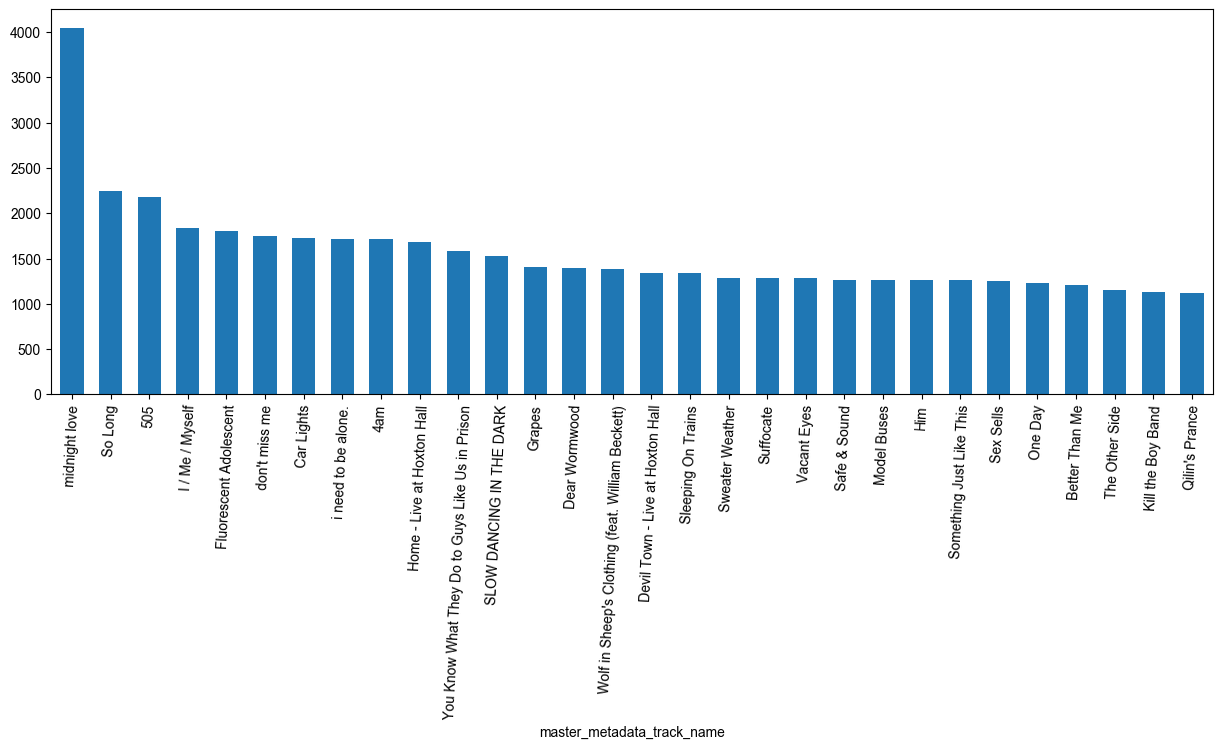

In [27]:
plt.rcParams['font.sans-serif'] = [
    'Arial Unicode MS',  
    'AppleGothic',   
    'PingFang SC',   
    'Malgun Gothic', 
    'Hiragino Sans',     
    'Yu Gothic',         
    'SimHei',        
    'Arial'          
]
plt.rcParams['axes.unicode_minus'] = False
counts[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)
plt.show()